### 전복 나이테 분류

202435119 한여원

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow.keras
from tensorflow.keras import models, layers

In [6]:
df = pd.read_csv(r'D:\hanyeowon\Coding\pythonworks\deep\data\abalone.csv')
print(df)
print(df.dtypes)
print(df.columns)

        id Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  \
0        0   M   0.455     0.365   0.095        0.5140          0.2245   
1        1   M   0.350     0.265   0.090        0.2255          0.0995   
2        2   F   0.530     0.420   0.135        0.6770          0.2565   
3        3   M   0.440     0.365   0.125        0.5160          0.2155   
4        4   I   0.330     0.255   0.080        0.2050          0.0895   
...    ...  ..     ...       ...     ...           ...             ...   
4172  4172   F   0.565     0.450   0.165        0.8870          0.3700   
4173  4173   M   0.590     0.440   0.135        0.9660          0.4390   
4174  4174   M   0.600     0.475   0.205        1.1760          0.5255   
4175  4175   F   0.625     0.485   0.150        1.0945          0.5310   
4176  4176   M   0.710     0.555   0.195        1.9485          0.9455   

      Viscera_weight  Shell_weight  Rings  
0             0.1010        0.1500     15  
1             0.0485   

In [7]:
df = pd.get_dummies(df, columns=['Sex'])
df = df.drop('id', axis=1)
rings = df['Rings']
print(df)

      Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0      0.455     0.365   0.095        0.5140          0.2245          0.1010   
1      0.350     0.265   0.090        0.2255          0.0995          0.0485   
2      0.530     0.420   0.135        0.6770          0.2565          0.1415   
3      0.440     0.365   0.125        0.5160          0.2155          0.1140   
4      0.330     0.255   0.080        0.2050          0.0895          0.0395   
...      ...       ...     ...           ...             ...             ...   
4172   0.565     0.450   0.165        0.8870          0.3700          0.2390   
4173   0.590     0.440   0.135        0.9660          0.4390          0.2145   
4174   0.600     0.475   0.205        1.1760          0.5255          0.2875   
4175   0.625     0.485   0.150        1.0945          0.5310          0.2610   
4176   0.710     0.555   0.195        1.9485          0.9455          0.3765   

      Shell_weight  Rings  Sex_F  Sex_I

In [9]:
print(max(rings), min(rings))


29 1


In [26]:
df['Age_Group'] = pd.cut(df['Rings'], bins=[0, 8, 12, 30], labels=[0, 1, 2])
print(df)
y = df['Age_Group']
X = df.drop('Age_Group', axis=1)


      Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0      0.455     0.365   0.095        0.5140          0.2245          0.1010   
1      0.350     0.265   0.090        0.2255          0.0995          0.0485   
2      0.530     0.420   0.135        0.6770          0.2565          0.1415   
3      0.440     0.365   0.125        0.5160          0.2155          0.1140   
4      0.330     0.255   0.080        0.2050          0.0895          0.0395   
...      ...       ...     ...           ...             ...             ...   
4172   0.565     0.450   0.165        0.8870          0.3700          0.2390   
4173   0.590     0.440   0.135        0.9660          0.4390          0.2145   
4174   0.600     0.475   0.205        1.1760          0.5255          0.2875   
4175   0.625     0.485   0.150        1.0945          0.5310          0.2610   
4176   0.710     0.555   0.195        1.9485          0.9455          0.3765   

      Shell_weight  Rings  Sex_F  Sex_I

In [27]:
print(X)
print(y)

      Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0      0.455     0.365   0.095        0.5140          0.2245          0.1010   
1      0.350     0.265   0.090        0.2255          0.0995          0.0485   
2      0.530     0.420   0.135        0.6770          0.2565          0.1415   
3      0.440     0.365   0.125        0.5160          0.2155          0.1140   
4      0.330     0.255   0.080        0.2050          0.0895          0.0395   
...      ...       ...     ...           ...             ...             ...   
4172   0.565     0.450   0.165        0.8870          0.3700          0.2390   
4173   0.590     0.440   0.135        0.9660          0.4390          0.2145   
4174   0.600     0.475   0.205        1.1760          0.5255          0.2875   
4175   0.625     0.485   0.150        1.0945          0.5310          0.2610   
4176   0.710     0.555   0.195        1.9485          0.9455          0.3765   

      Shell_weight  Rings  Sex_F  Sex_I

In [32]:
print(X.dtypes)

Length            float64
Diameter          float64
Height            float64
Whole_weight      float64
Shucked_weight    float64
Viscera_weight    float64
Shell_weight      float64
Rings               int64
Sex_F                bool
Sex_I                bool
Sex_M                bool
dtype: object


In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_train = np.array(y_train).astype('int')
y_test = np.array(y_test).astype('int')

In [34]:
model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1], )),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(y.shape[1], activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50


d:\hanyeowon\Coding\pythonworks\deep\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7098 - loss: 1.0790 - val_accuracy: 0.8501 - val_loss: 0.4184
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8675 - loss: 0.3659 - val_accuracy: 0.9633 - val_loss: 0.1920
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9214 - loss: 0.2354 - val_accuracy: 0.9793 - val_loss: 0.1260
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9477 - loss: 0.1611 - val_accuracy: 0.9936 - val_loss: 0.0732
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9577 - loss: 0.1065 - val_accuracy: 0.9841 - val_loss: 0.0451
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9581 - loss: 0.0917 - val_accuracy: 0.9777 - val_loss: 0.0330
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9525 - loss: 0.0671 - val_accuracy: 0.9697 - val_loss: 0.0240
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9561 - loss: 0.0524 - val_accuracy: 0.9569 - val_

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


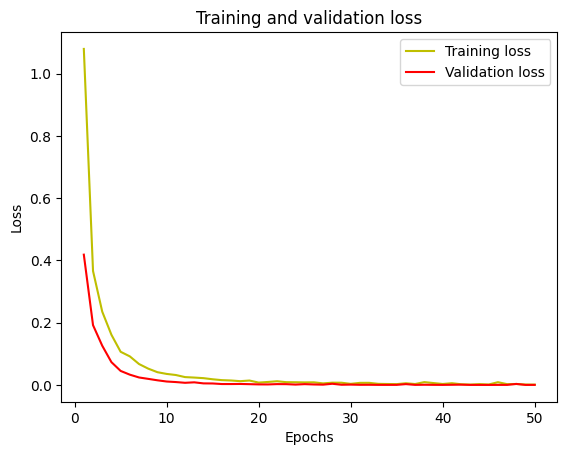

In [37]:
y_pred = model.predict(X_test_scaled)


loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
import matplotlib.pyplot as plt

epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [38]:
print(loss)
print(val_loss)
print(acc)

[1.0789809226989746, 0.3659174144268036, 0.23544053733348846, 0.1610855609178543, 0.10651681572198868, 0.09174103289842606, 0.06714950501918793, 0.052357267588377, 0.04094831645488739, 0.03542570769786835, 0.03191189467906952, 0.02520134299993515, 0.0237208753824234, 0.021845415234565735, 0.01822398416697979, 0.015440245158970356, 0.01431144867092371, 0.012123017571866512, 0.014189817942678928, 0.007573739625513554, 0.009590910747647285, 0.011937187053263187, 0.00892613921314478, 0.008701764978468418, 0.008149776607751846, 0.0084645701572299, 0.005028747487813234, 0.007273244205862284, 0.007143313996493816, 0.003525919746607542, 0.006710132583975792, 0.006802687421441078, 0.0035339074674993753, 0.003005967941135168, 0.0026492327451705933, 0.005456848535686731, 0.0029568958561867476, 0.009089061990380287, 0.006064073648303747, 0.0030942060984671116, 0.005627737380564213, 0.0022115816827863455, 0.0011923863785341382, 0.0027104327455163, 0.001444299821741879, 0.008880560286343098, 0.00255

In [43]:
print(y_test.shape)
print(y_pred.shape)
y_pred_class = np.argmax(y_pred, axis=1)

(1045,)
(1045, 30)


In [44]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred_class))
print(confusion_matrix(y_test,y_pred_class))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       376
           1       0.94      1.00      0.97       505
           2       1.00      0.79      0.88       164

    accuracy                           0.97      1045
   macro avg       0.98      0.93      0.95      1045
weighted avg       0.97      0.97      0.97      1045

[[376   0   0]
 [  0 505   0]
 [  0  34 130]]
